In [1]:
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
import pandas as pd

In [2]:
df_merged = pd.read_csv('covalent_noncovalent_MorganFP_bits_dataset.csv')
df_merged_base = df_merged[(df_merged['source'] == 'open_database') & (df_merged['cov_label'] == 0)]
df_merged_base = df_merged_base.iloc[:,:3]
df_merged_base['mol'] = df_merged_base['smiles'].apply(lambda x: Chem.MolFromSmiles(x))
df_merged_base['scaffold'] = df_merged_base['mol'].apply(lambda x: Chem.MolFromSmiles(MurckoScaffold.MurckoScaffoldSmiles(mol=x)))

Total number of scaffolds: 4170
Number of scaffolds successfully substituted: 4112
Number of scaffolds not substituted: 58
Total number of substituted scaffolds: 17975


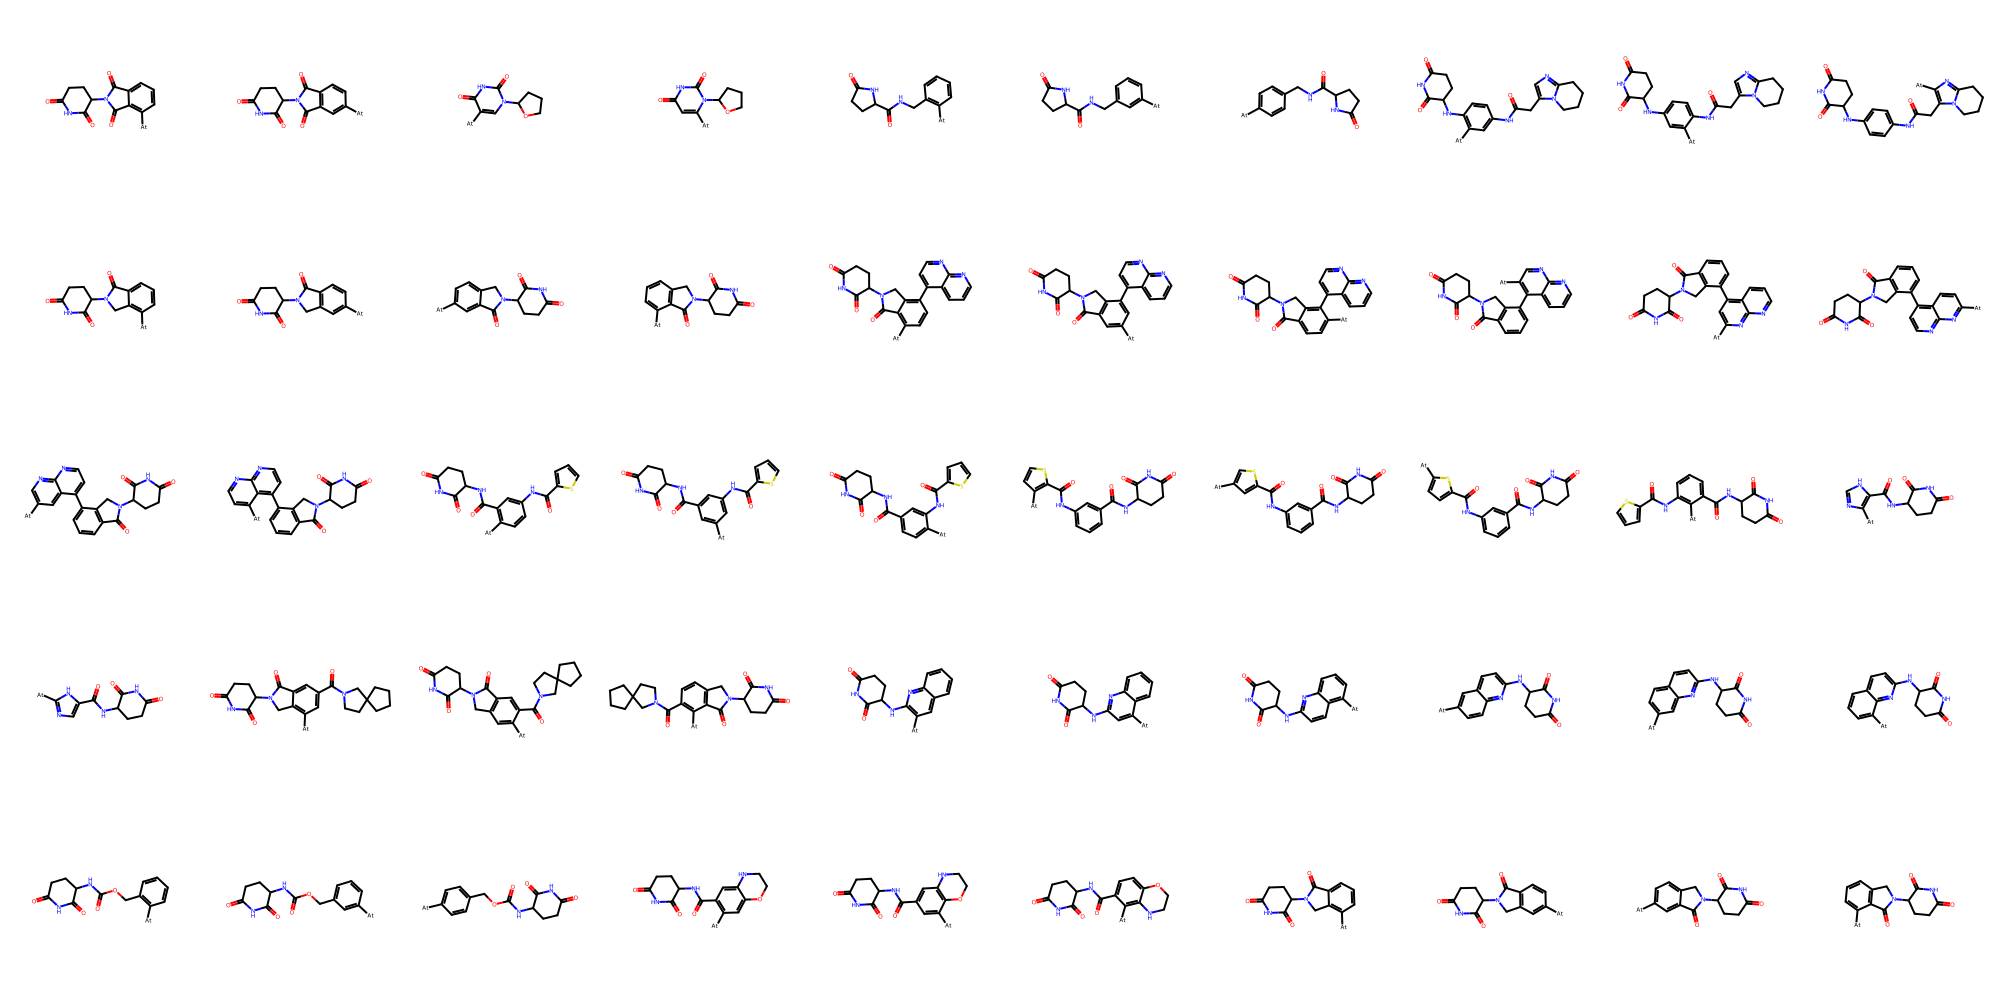

In [3]:
mols = df_merged_base['scaffold'].tolist()
print(f'Total number of scaffolds: {len(mols)}')

# Define Reaction to replace Hydrogen on aromatic carbon with Astatine
# [c:1][H] matches aromatic carbon (1) attached to Hydrogen
# [c:1][At] keeps the carbon and attaches Astatine
replace_h_rxn = AllChem.ReactionFromSmarts('[c:1][H]>>[c:1][At]')

substrate = []
sub_count = 0
unsub_count = 0 
for mol in mols:
    try:
        # Add explicit hydrogens to allow reaction with H
        mol_h = Chem.AddHs(mol)
        
        # Run the reaction
        # RunReactants returns a tuple of tuples of products
        # For each match of the reactants, one tuple of products is generated
        products_tuples = replace_h_rxn.RunReactants((mol_h,))
        
        valid_replaced = []
        for prod_tuple in products_tuples:
            for prod in prod_tuple:
                try:
                    # Remove Hs (this will remove the other Hs, but keep At)
                    # Note: At is not H, so it stays.
                    r = Chem.RemoveHs(prod)
                    Chem.SanitizeMol(r)
                    valid_replaced.append(r)
                except:
                    pass
        
        # Deduplicate if necessary (sometimes symmetry causes duplicates)
        # Using SMILES for deduplication
        unique_smiles = set()
        unique_mols = []
        for m in valid_replaced:
            smi = Chem.MolToSmiles(m)
            if smi not in unique_smiles:
                unique_smiles.add(smi)
                unique_mols.append(m)

        if unique_mols:
            substrate.extend(unique_mols)
            sub_count += 1
        else:
            unsub_count += 1
    except Exception as e:
        # print(e) # Optional debugging
        unsub_count += 1

print(f'Number of scaffolds successfully substituted: {sub_count}')
print(f'Number of scaffolds not substituted: {unsub_count}')
print(f'Total number of substituted scaffolds: {len(substrate)}')

if len(substrate) > 0:
    display(Draw.MolsToGridImage(substrate[:50], molsPerRow=10, subImgSize=(200,200)))
else:
    print("No substrates generated.")

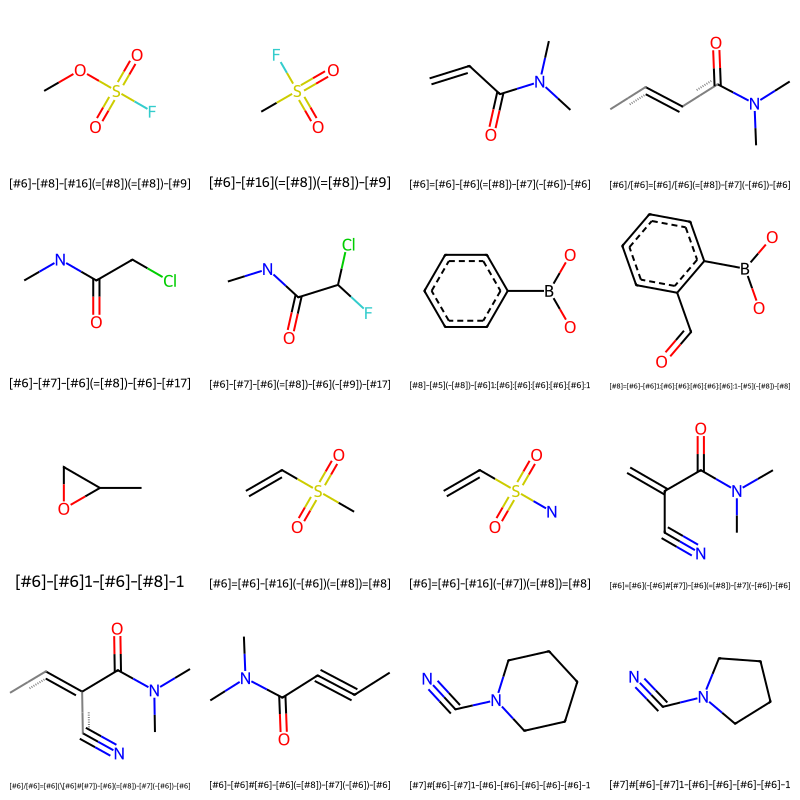

In [4]:
covalent_smiles_list = [
'COS(=O)(=O)F',
'CS(=O)(=O)F',
'C=CC(=O)N(C)C',
'C/C=C/C(=O)N(C)C',
'CNC(=O)CCl',
'CNC(=O)C(F)Cl',
'OB(O)c1ccccc1',
'O=Cc1ccccc1B(O)O',
'CC1CO1',
'C=CS(C)(=O)=O',
'C=CS(N)(=O)=O',
'C=C(C#N)C(=O)N(C)C',
'C/C=C(\C#N)C(=O)N(C)C',
'CC#CC(=O)N(C)C',
'N#CN1CCCCC1',
'N#CN1CCCC1'
]
smarts_mol_list = []
smarts_list = []
for i in covalent_smiles_list:
    mol = Chem.MolFromSmiles(i)
    Chem.SanitizeMol(mol)
    smarts = Chem.MolToSmarts(mol)
    smarts_list.append(smarts)
    smarts_mol = Chem.MolFromSmarts(smarts)
    smarts_mol_list.append(smarts_mol)
Draw.MolsToGridImage(smarts_mol_list, molsPerRow=4, legends=smarts_list, subImgSize=(200,200))

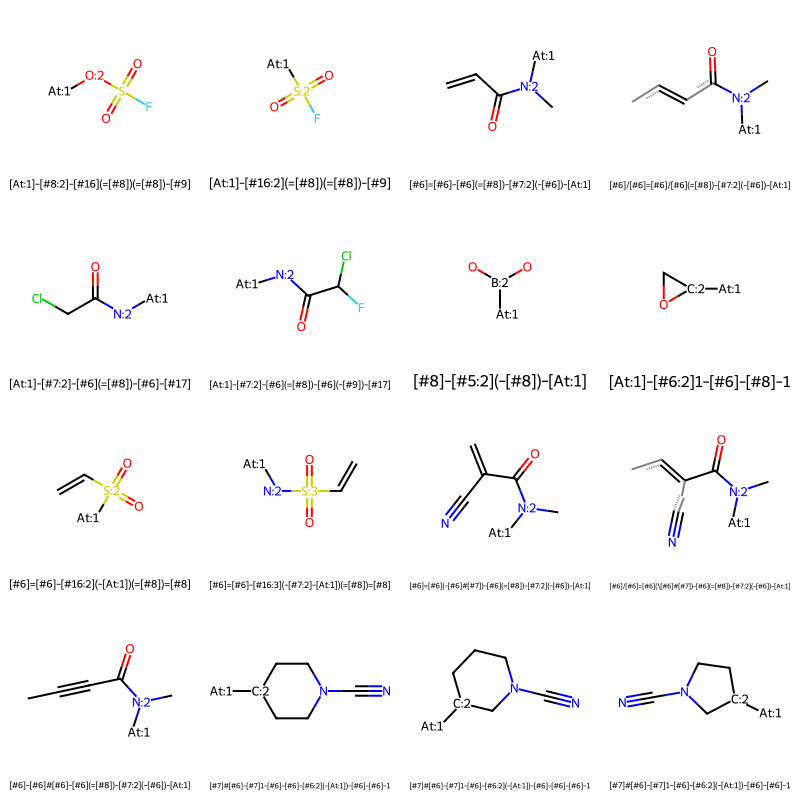

In [5]:
covalent_sub_list = [
'[At:1]-[#8:2]-[#16](=[#8])(=[#8])-[#9]',
'[At:1]-[#16:2](=[#8])(=[#8])-[#9]',
'[#6]=[#6]-[#6](=[#8])-[#7:2](-[#6])-[At:1]',
'[#6]/[#6]=[#6]/[#6](=[#8])-[#7:2](-[#6])-[At:1]',
'[At:1]-[#7:2]-[#6](=[#8])-[#6]-[#17]',
'[At:1]-[#7:2]-[#6](=[#8])-[#6](-[#9])-[#17]',
'[#8]-[#5:2](-[#8])-[At:1]',
'[At:1]-[#6:2]1-[#6]-[#8]-1',
'[#6]=[#6]-[#16:2](-[At:1])(=[#8])=[#8]',
'[#6]=[#6]-[#16:3](-[#7:2]-[At:1])(=[#8])=[#8]',
'[#6]=[#6](-[#6]#[#7])-[#6](=[#8])-[#7:2](-[#6])-[At:1]',
'[#6]/[#6]=[#6](\\[#6]#[#7])-[#6](=[#8])-[#7:2](-[#6])-[At:1]',
'[#6]-[#6]#[#6]-[#6](=[#8])-[#7:2](-[#6])-[At:1]',
'[#7]#[#6]-[#7]1-[#6]-[#6]-[#6:2](-[At:1])-[#6]-[#6]-1',
'[#7]#[#6]-[#7]1-[#6]-[#6:2](-[At:1])-[#6]-[#6]-[#6]-1',
'[#7]#[#6]-[#7]1-[#6]-[#6:2](-[At:1])-[#6]-[#6]-1'
]
warheads =[]
for i in covalent_sub_list:
    warhead = Chem.MolFromSmarts(i)
    Chem.SanitizeMol(warhead)
    warheads.append(warhead)
Draw.MolsToGridImage(warheads, molsPerRow=4, legends=covalent_sub_list, subImgSize=(200,200))

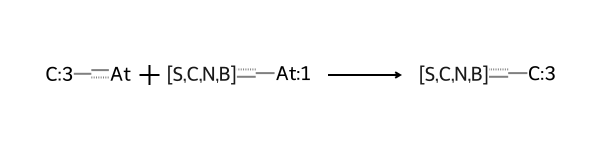

In [6]:
smarts_two_components_rxn = '[c:3][At].[At:1][S,C,N,B:2]>>[c:3][S,C,N,B:2]'
rxn = AllChem.ReactionFromSmarts(smarts_two_components_rxn)
rxn

Starting reaction with 17975 substrates and 16 warheads...


[16:38:33] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 1 


Total generated compounds: 269625


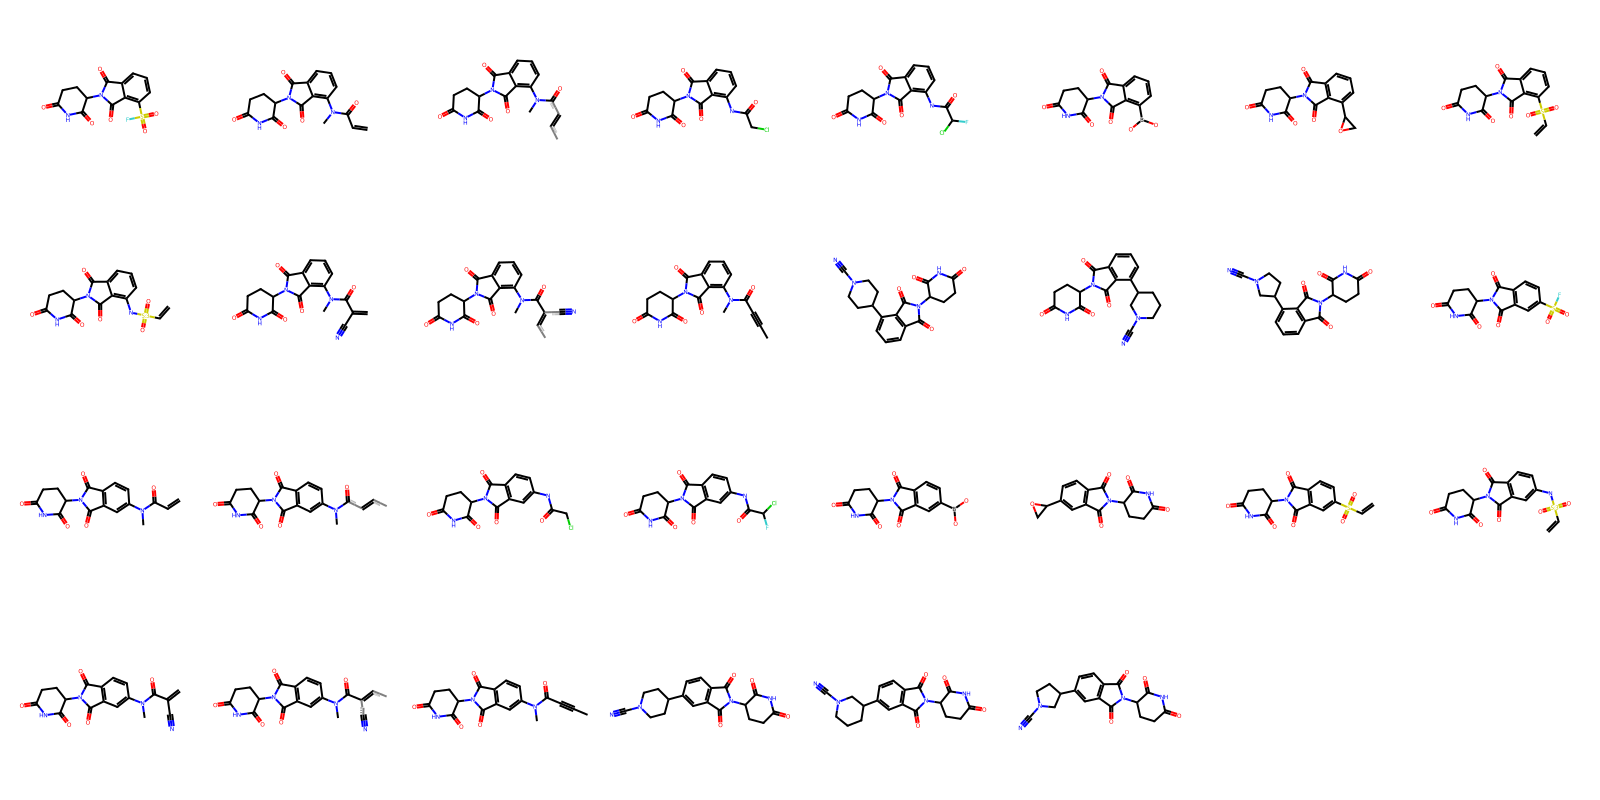

In [7]:
generated_compounds = []
print(f"Starting reaction with {len(substrate)} substrates and {len(warheads)} warheads...")

for sub_mol in substrate:
    for warhead_mol in warheads:
        try:
            products = rxn.RunReactants((sub_mol, warhead_mol))           
            for product_tuple in products:
                for prod in product_tuple:
                    try:
                        Chem.SanitizeMol(prod)
                        generated_compounds.append(prod)
                        #print('successfully generated compound')
                    except:
                        #print('failed to sanitize product')
                        continue
        except:
            #print('failed to react substrate and warhead')
            continue

print(f"Total generated compounds: {len(generated_compounds)}")
Draw.MolsToGridImage(generated_compounds[:30], molsPerRow=8, subImgSize=(200,200))

In [8]:
df_badsubstructures = pd.read_csv("unwanted_substructures.csv")
df_bad_excpet_cov = df_badsubstructures.loc[~df_badsubstructures['name'].isin(['alkyl-halide',
                                                                            'conjugated-nitrile-group',
                                                                            'cyanamide',
                                                                            'isolate-alkene',
                                                                            'Michael-acceptor',
                                                                            'phosphor-P-phthalimide',
                                                                            'triple-bond'])]

In [9]:
df_bad_excpet_cov.loc[df_bad_excpet_cov['name'].isin(['heavy-metal', 'Three-membered-heterocycle', 'cyanate/aminonitrile/thiocyanate'])]

,name,smarts
27,cyanate/aminonitrile/thiocyanate,"[N,O,S]C#N"
44,heavy-metal,"[Hg,Fe,As,Sb,Zn,Se,se,Te,B,Si]"
100,Three-membered-heterocycle,"*1[O,S,N]*1"


In [10]:
df_bad_excpet_cov.loc[df_bad_excpet_cov['name'] == 'Three-membered-heterocycle', 'smarts'] = '*1[S,N]*1'
df_bad_excpet_cov.loc[df_bad_excpet_cov['name'] == 'heavy-metal', 'smarts'] = '[Hg,Fe,As,Sb,Zn,Se,se,Te,Si]'
df_bad_excpet_cov.loc[df_bad_excpet_cov['name'] == 'cyanate/aminonitrile/thiocyanate', 'smarts'] = '[O,S]C#N'

/tmp/ipykernel_51634/1541893138.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bad_excpet_cov.loc[df_bad_excpet_cov['name'] == 'Three-membered-heterocycle', 'smarts'] = '*1[S,N]*1'
/tmp/ipykernel_51634/1541893138.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bad_excpet_cov.loc[df_bad_excpet_cov['name'] == 'heavy-metal', 'smarts'] = '[Hg,Fe,As,Sb,Zn,Se,se,Te,Si]'
/tmp/ipykernel_51634/1541893138.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#return

In [11]:
df_bad_excpet_cov.loc[df_bad_excpet_cov['name'].isin(['heavy-metal', 'Three-membered-heterocycle', 'cyanate/aminonitrile/thiocyanate'])]

,name,smarts
27,cyanate/aminonitrile/thiocyanate,"[O,S]C#N"
44,heavy-metal,"[Hg,Fe,As,Sb,Zn,Se,se,Te,Si]"
100,Three-membered-heterocycle,"*1[S,N]*1"


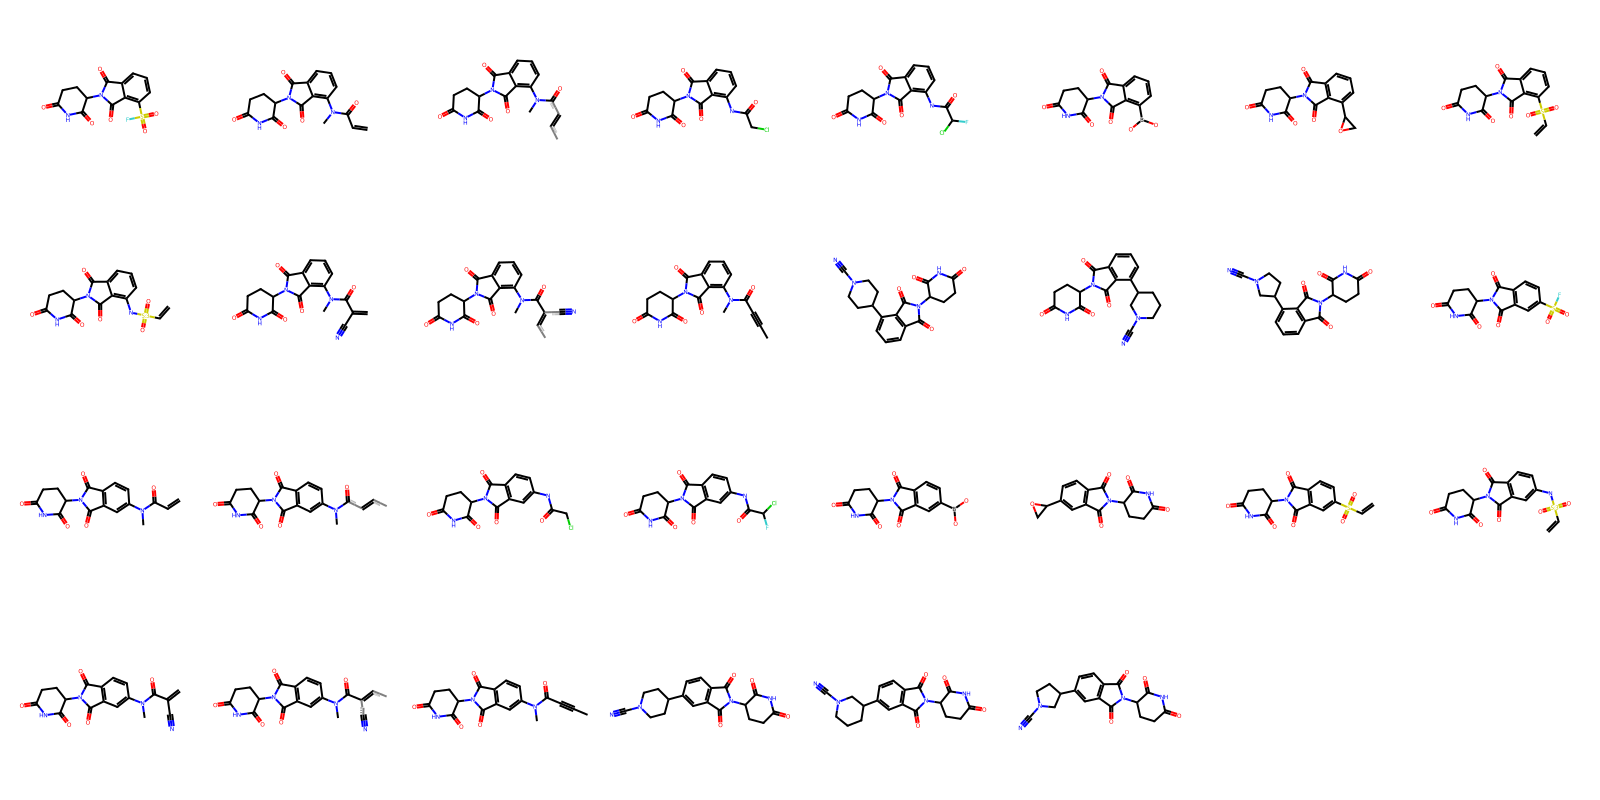

In [12]:
generated_compounds_testlist = generated_compounds[:30]
bad_dict = {}
for n, s in df_bad_excpet_cov[['name', 'smarts']].itertuples(index=False):
    bad_dict[n] = Chem.MolFromSmarts(s)

undesired = []
clean = []

for m in generated_compounds_testlist:
    match = False
    for substrate_name, substructure in bad_dict.items():
        if m.HasSubstructMatch(substructure):
            display(Draw.MolToImage(m, size=(300,300), legend=f'Matched undesired substructure: {substrate_name}'))
            undesired.append(m)
            match = True
            break
    if not match:
        clean.append(m)

Draw.MolsToGridImage(clean, molsPerRow=8, subImgSize=(200,200))

In [13]:
undesired = []
clean = []

for m in generated_compounds:
    match = False
    for substrate_name, substructure in bad_dict.items():
        if m.HasSubstructMatch(substructure):
            #display(Draw.MolToImage(m, size=(300,300), legend=f'Matched undesired substructure: {substrate_name}'))
            undesired.append(m)
            match = True
            break
    if not match:
        clean.append(m)

print(len(undesired), len(clean))

6765 262860


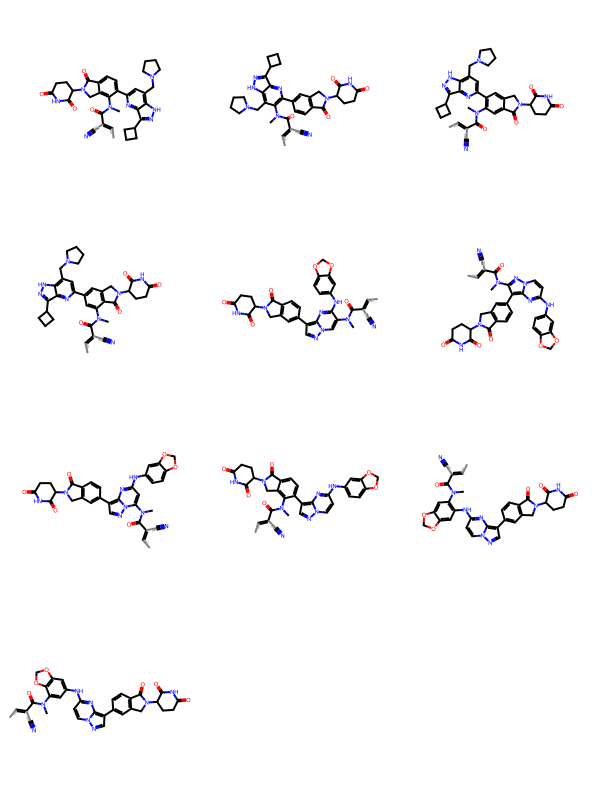

In [14]:
clean = sorted(clean, key=lambda x: Descriptors.MolWt(x), reverse=True)
Draw.MolsToGridImage(clean[:10])

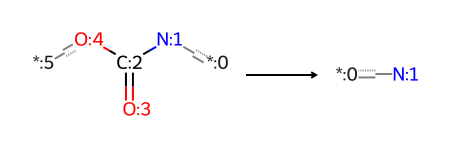

In [15]:
DEPROTECTION_RULES = {
    'Amine-deprotection': '[*:5][O:4]-[C:2](=[O:3])-[N:1][*:0]>>[N:1][*:0]'
}
#
reactions = [AllChem.ReactionFromSmarts(s) for s in DEPROTECTION_RULES.values()]
reactions[0]

In [18]:
def remove_all_protecting_groups(mol):        
    for rxn in reactions:
        try:
            products = rxn.RunReactants((mol,))
            if products:
                new_mol = products[0][0]
                Chem.SanitizeMol(new_mol)
                return new_mol
        except:
            pass

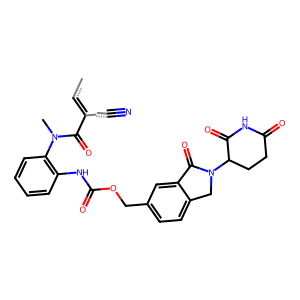

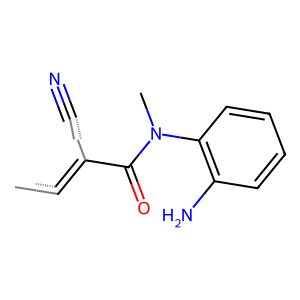

In [19]:
for i in clean:
    res = remove_all_protecting_groups(i)
    if res:
        display(Draw.MolToImage(i))
        display(Draw.MolToImage(res))
        break